In [1]:
import pandas as pd 
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# 네트워크 정보

In [2]:
unit_mob = 200

In [3]:
nodelist = pd.read_csv("data\\nodelist_connected.csv")
edgelist = pd.read_csv("data\\edgelist_symmetric.csv")

edgelist["mobility"] = edgelist["Max. Number of Routes"] * unit_mob
nodelist = nodelist.set_index("ID")

In [4]:
num_nodes = len(nodelist)
num_edges = len(edgelist)

global_pop = nodelist["Population"].sum()
global_mob = edgelist["mobility"].sum()

# 결과 로드

In [35]:
results = pd.read_csv("results\\random-R0_1.0-results.csv")
temp = pd.read_csv("results\\random-R0_1.0-additional-results.csv")
results = pd.concat((results, temp), ignore_index=True)

for r in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    temp = pd.read_csv(f"results\\random-R0_{r}-results.csv")
    results = pd.concat((results, temp), ignore_index=True)

results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4819500 entries, 0 to 4819499
Data columns (total 15 columns):
 #   Column                                  Dtype  
---  ------                                  -----  
 0   Number of edge cuts                     int64  
 1   Edge cut seed                           int64  
 2   Total mobility cut                      float64
 3   Largest connected component size        int64  
 4   Maximum connected component population  float64
 5   Diameter                                float64
 6   Average distance                        float64
 7   Basic reproduction number               float64
 8   Recovery time                           float64
 9   Global effective reproduciton number    float64
 10  Infection origin                        int64  
 11  Solver message                          object 
 12  Peak severity                           float64
 13  Peak time                               float64
 14  Global attack rate                

In [36]:
np.sum(results["Solver message"] != "A termination event occurred.") / len(results) * 100

0.5235397862848843

In [37]:
results.loc[results["Solver message"] != "A termination event occurred."].head()

,Number of edge cuts,Edge cut seed,Total mobility cut,Largest connected component size,Maximum connected component population,Diameter,Average distance,Basic reproduction number,Recovery time,Global effective reproduciton number,Infection origin,Solver message,Peak severity,Peak time,Global attack rate
19298,46,12,45200.0,224,7.354872e+09,5.0,2.344130,1.0,28.0,1.0,173,The solver successfully reached the end of the...,0.0,0.0,0.0
28748,92,3,103600.0,224,7.354872e+09,5.0,2.343970,1.0,28.0,1.0,173,The solver successfully reached the end of the...,0.0,0.0,0.0
36398,92,20,138000.0,224,7.354872e+09,5.0,2.354901,1.0,28.0,1.0,173,The solver successfully reached the end of the...,0.0,0.0,0.0
46748,138,13,161200.0,224,7.354872e+09,5.0,2.352619,1.0,28.0,1.0,173,The solver successfully reached the end of the...,0.0,0.0,0.0
50798,138,22,195200.0,224,7.354872e+09,5.0,2.359865,1.0,28.0,1.0,173,The solver successfully reached the end of the...,0.0,0.0,0.0


In [38]:
np.sum(results["Global effective reproduciton number"] == 0.0)

225

In [39]:
results.loc[results["Global effective reproduciton number"] == 0.0, ["Number of edge cuts", "Edge cut seed"]]

,Number of edge cuts,Edge cut seed
658800,2208,24
658801,2208,24
658802,2208,24
658803,2208,24
658804,2208,24
...,...,...
659020,2208,24
659021,2208,24
659022,2208,24
659023,2208,24


In [40]:
results = results.loc[results["Solver message"] == "A termination event occurred."]

In [41]:
results["Relative largest connected component size"] = results["Largest connected component size"] / num_nodes
results["Maximum connected component population fraction"] = results["Maximum connected component population"] / global_pop

results["Fraction of edge cuts"] = results["Number of edge cuts"] / num_edges
results["Fraction of mobility cuts"] = results["Total mobility cut"] / global_mob

# 시각화

In [42]:
basic_rep = 2.0
r_time = 14.0

sample = results.loc[(results["Basic reproduction number"] == basic_rep) & (results["Recovery time"] == r_time)]

## 네트워크 측정량들

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

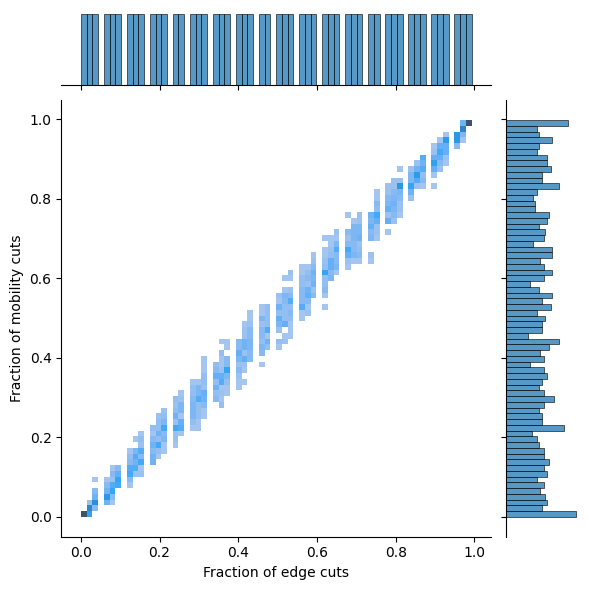

In [53]:
sns.jointplot(data=sample, x="Fraction of edge cuts", y="Fraction of mobility cuts", kind="hist")

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

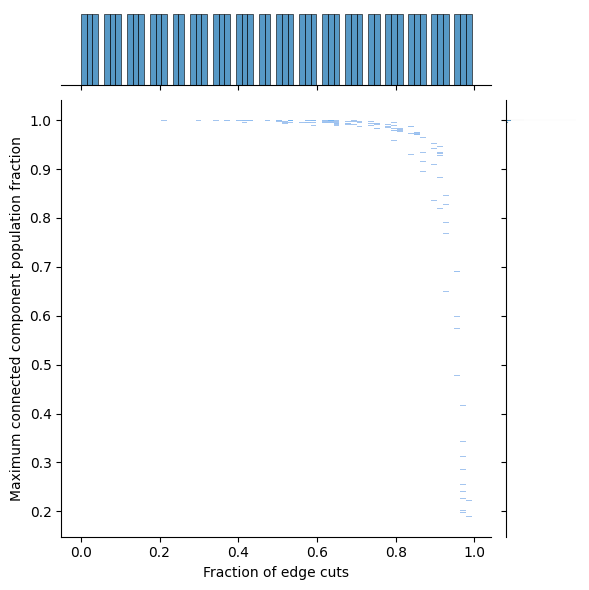

In [57]:
sns.jointplot(data=sample, x="Fraction of edge cuts", y="Maximum connected component population fraction", kind="hist")

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

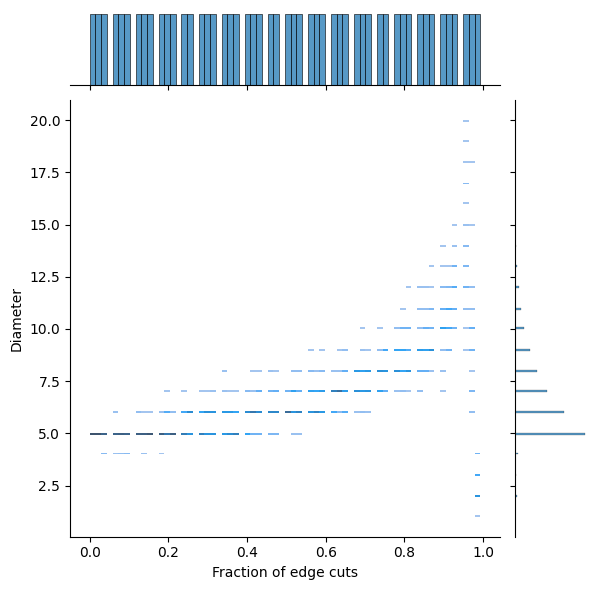

In [58]:
sns.jointplot(data=sample, x="Fraction of edge cuts", y="Diameter", kind="hist")

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

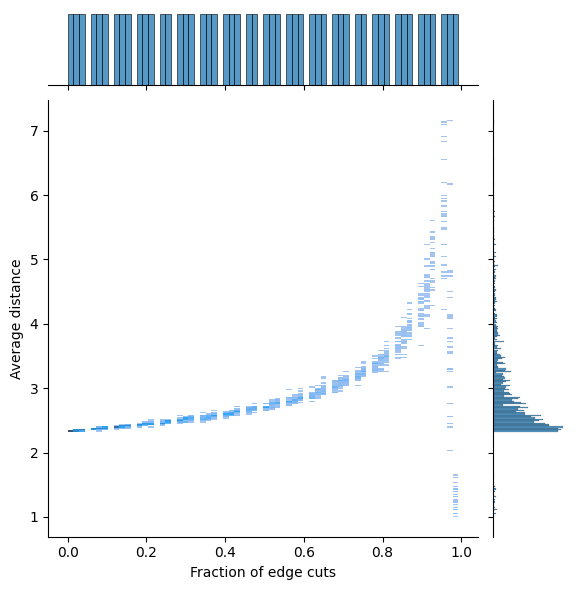

In [59]:
sns.jointplot(data=sample, x="Fraction of edge cuts", y="Average distance", kind="hist")

## Global attack rate

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

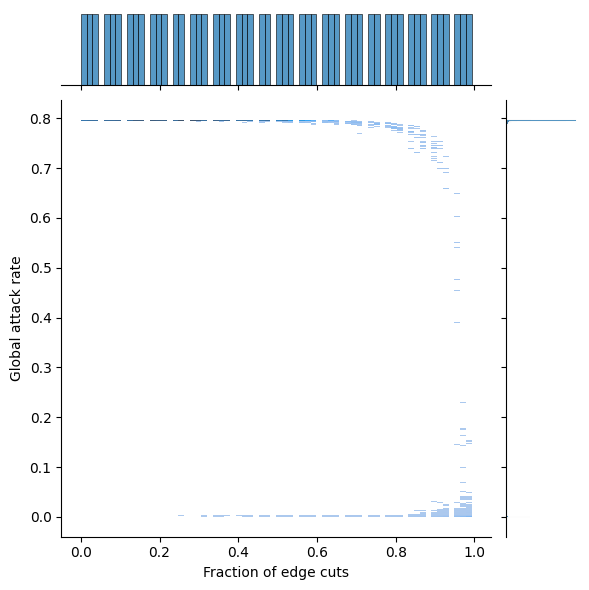

In [65]:
sns.jointplot(data=sample, x="Fraction of edge cuts", y="Global attack rate", kind="hist")

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

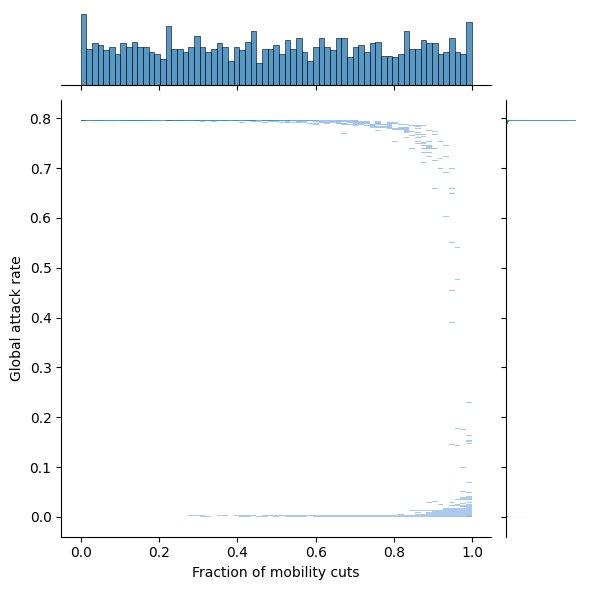

In [67]:
sns.jointplot(data=sample, x="Fraction of mobility cuts", y="Global attack rate", kind="hist")

Text(0.5, 1.0, 'Global attack rate vs. Fraction of population in the LCC')

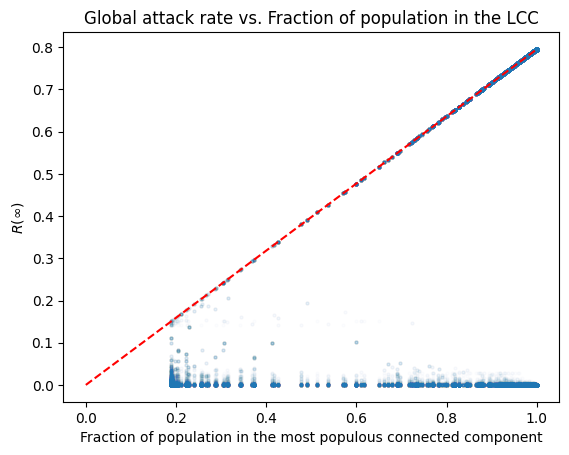

In [71]:
plt.scatter(sample["Maximum connected component population fraction"], sample["Global attack rate"], alpha=0.01, s=5)
plt.plot([0, 1.0], [0.0, sample.loc[sample["Number of edge cuts"] == 0, "Global attack rate"].mean()], color='red', linestyle='--')

plt.xlabel("Fraction of population in the most populous connected component")
plt.ylabel("$R(\infty)$")

plt.title(f"Global attack rate vs. Fraction of population in the LCC")

### 3D

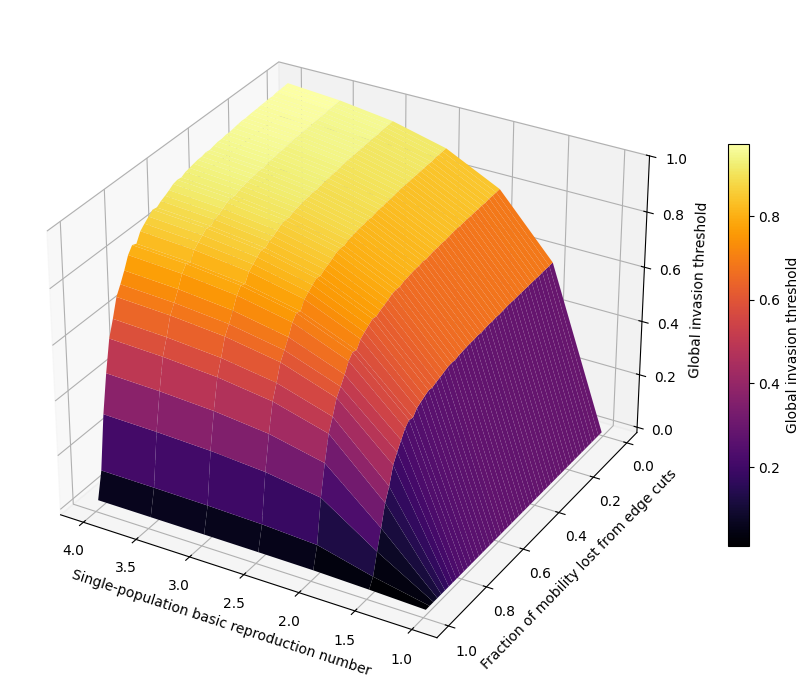

In [77]:
# R bins: edges 0.75, 1.25, ..., 4.25  -> 7 bins centered at 1.0, 1.5, ..., 4.0
R_edges = np.arange(0.75, 4.25 + 1e-9, 0.5)
R_centers = 0.5 * (R_edges[:-1] + R_edges[1:])

# f bins: 50 evenly spaced bins
f_min, f_max = results['Fraction of mobility cuts'].min(), results['Fraction of mobility cuts'].max()
f_edges = np.linspace(f_min, f_max, 51)
f_centers = 0.5 * (f_edges[:-1] + f_edges[1:])

# Assign each row to a bin
R_idx = np.digitize(results['Basic reproduction number'].values, R_edges) - 1
f_idx = np.digitize(results['Fraction of mobility cuts'].values, f_edges) - 1

# Clip to valid range (handles f == f_max edge case)
R_idx = np.clip(R_idx, 0, len(R_centers) - 1)
f_idx = np.clip(f_idx, 0, len(f_centers) - 1)

# Compute mean I per (R_bin, f_bin)
nR, nF = len(R_centers), len(f_centers)
sum_I = np.zeros((nR, nF))
cnt   = np.zeros((nR, nF))
np.add.at(sum_I, (R_idx, f_idx), results['Global attack rate'].values)
np.add.at(cnt,   (R_idx, f_idx), 1)

with np.errstate(invalid='ignore', divide='ignore'):
    mean_I = np.where(cnt > 0, sum_I / cnt, np.nan)

# Surface plot
R_grid, F_grid = np.meshgrid(R_centers, f_centers, indexing='ij')

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    R_grid, F_grid, mean_I,
    cmap='inferno',
    edgecolor='none',
    linewidth=0,
    antialiased=True,
)
ax.view_init(elev=30, azim=120)
ax.set_xlabel('Single-population basic reproduction number')
ax.set_ylabel('Fraction of mobility lost from edge cuts')
ax.set_zlabel('Global invasion threshold')
fig.colorbar(surf, ax=ax, shrink=0.6, label='Global invasion threshold')
plt.tight_layout()
plt.show()

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

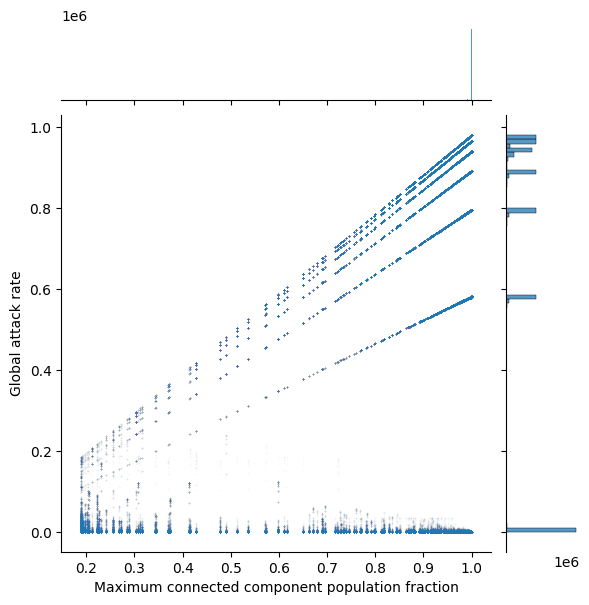

In [78]:
sns.jointplot(data=results, x="Maximum connected component population fraction", y="Global attack rate", kind="scatter", s=2, alpha=0.01)

## Peak time

Text(0.5, 1.0, 'Peak time vs. Fraction of mobility cuts')

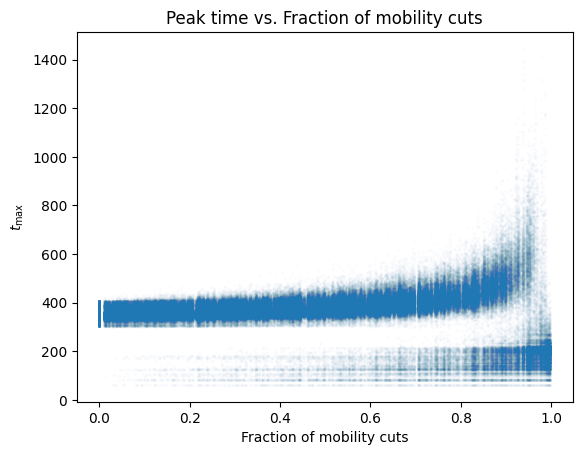

In [79]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Peak time"], alpha=0.01, s=2)

plt.xlabel("Fraction of mobility cuts")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Fraction of mobility cuts")

Text(0.5, 1.0, 'Peak time vs. Diameter')

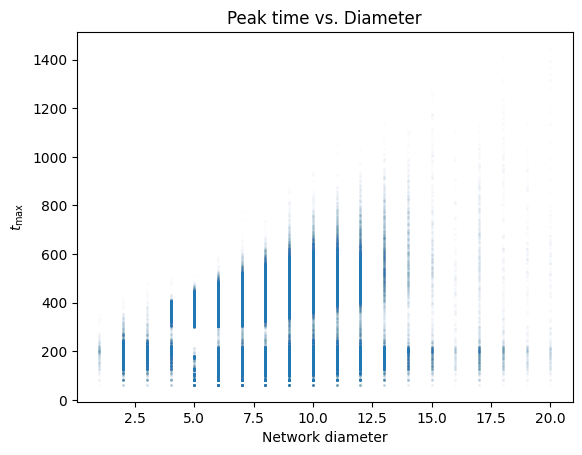

In [80]:
plt.scatter(sample["Diameter"], sample["Peak time"], alpha=0.01, s=2)

plt.xlabel("Network diameter")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Diameter")

Text(0.5, 1.0, 'Peak time vs. Average distance')

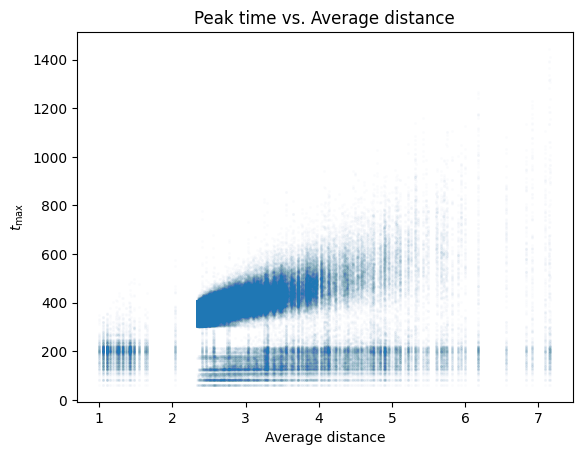

In [81]:
plt.scatter(sample["Average distance"], sample["Peak time"], alpha=0.01, s=2)

plt.xlabel("Average distance")
plt.ylabel("$t_\\text{max}$")

plt.title(f"Peak time vs. Average distance")

## Peak severity

Text(0.5, 1.0, 'Peak severity vs. Fraction of mobility cuts')

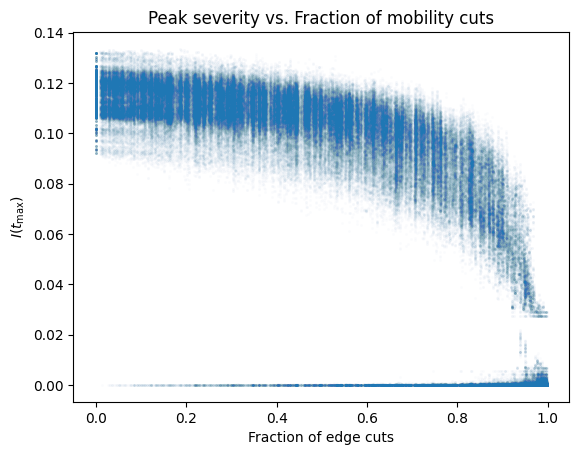

In [82]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Peak severity"], alpha=0.01, s=2)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$I(t_\\text{max})$")

plt.title(f"Peak severity vs. Fraction of mobility cuts")

Text(0.5, 1.0, 'Peak severity vs. Fraction of population in the LCC')

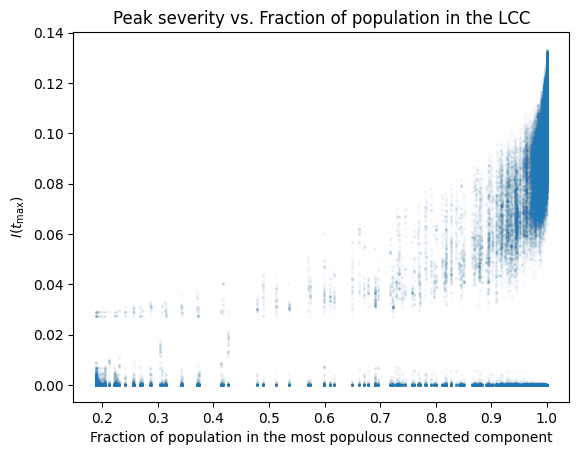

In [85]:
plt.scatter(sample["Maximum connected component population fraction"], sample["Peak severity"], alpha=0.01, s=2)

plt.xlabel("Fraction of population in the most populous connected component")
plt.ylabel("$I(t_\\text{max})$")

plt.title(f"Peak severity vs. Fraction of population in the LCC")

## Global effective reproduction number

Text(0.5, 1.0, 'Effective reproduction number vs. Fraction of edge cuts')

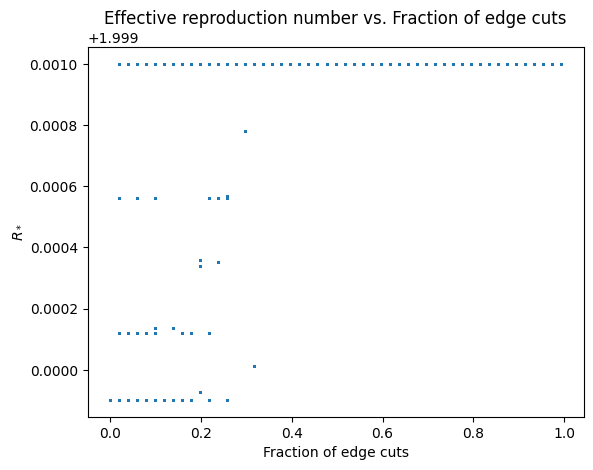

In [86]:
plt.scatter(sample["Fraction of edge cuts"], sample["Global effective reproduciton number"], alpha=0.01, s=2)

plt.xlabel("Fraction of edge cuts")
plt.ylabel("$R_*$")

plt.title(f"Effective reproduction number vs. Fraction of edge cuts")

Text(0.5, 1.0, 'Effective reproduction number vs. Fraction of mobility cuts')

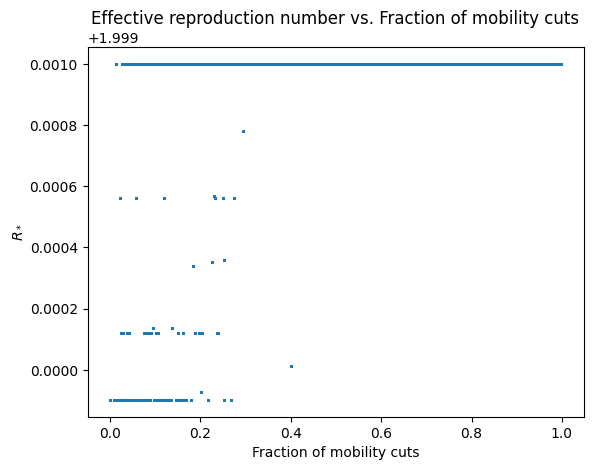

In [87]:
plt.scatter(sample["Fraction of mobility cuts"], sample["Global effective reproduciton number"], alpha=0.01, s=2)

plt.xlabel("Fraction of mobility cuts")
plt.ylabel("$R_*$")

plt.title(f"Effective reproduction number vs. Fraction of mobility cuts")